# Get Rain from MERGE

In [6]:
%load_ext autoreload
%autoreload 2

import json
import logging
from pathlib import Path

import geopandas as gpd
import pandas as pd
from mergedownloader.downloader import Downloader
from mergedownloader.file_downloader import ConnectionType, DownloadMode, FileDownloader
from mergedownloader.inpeparser import INPE_SERVER, InpeParsers, InpeTypes
from mergedownloader.utils import GISUtil


## Constants

In [26]:
BASIN = "PortoMurtinho"
STATION = 67100000


path = Path(f"/data/CN3S/basins/{BASIN}")
assert path.exists(), f"Path {path} does not exist"

## Load Basin boundaries

<Axes: >

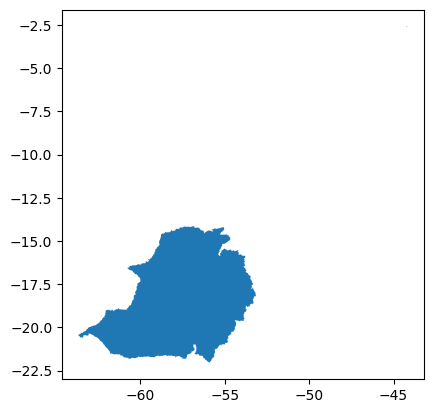

In [27]:
basin = gpd.read_parquet(f"/data/CN3S/basins/{BASIN}/DA_Station_{STATION}.parquet")
basin.plot()


In [28]:
# calculate the area in squared kilometers of basin (need to reproject to an equal-area projection first)
basin = basin.to_crs("epsg:32723")
basin["area_km2"] = basin.geometry.area / 1e6
print(f"Basin area: {basin['area_km2'].iloc[0]:.2f} km²")

Basin area: 586884.01 km²


In [29]:
data = {
    "station": STATION,
    "area": basin["area_km2"].iloc[0],
}

In [30]:
with (path / "metadata.json").open("w") as f:
    json.dump(data, f)

with (path / "metadata.json").open("r") as f:
    metadata = json.load(f)

metadata

{'station': 67100000, 'area': 586884.0126323648}

## Create Downloader

In [31]:
fd = FileDownloader(
    server=INPE_SERVER,
    connection_type=ConnectionType.HTTP,
    download_mode=DownloadMode.NO_UPDATE,
    log_level=logging.DEBUG,
)

downloader = Downloader(
    file_downloader=fd,
    local_folder="/data/CN3S/downloads",
    parsers=InpeParsers,
    log_level=logging.DEBUG,
)


Using wget through HTTP on: ftp.cptec.inpe.br


## Get MONTHLY MERGE Rain for Basin

In [32]:
cube = downloader.create_cube(
    "2000-01-01",
    "2026-05-01",
    InpeTypes.MONTHLY_ACCUM_YEARLY,
)


In [33]:
cube_clipped = GISUtil.cut_cube_by_geoms(cube, basin.geometry)

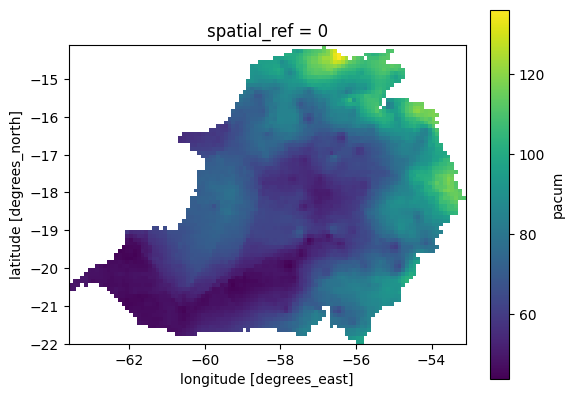

In [34]:
ax = basin.plot(color="none", edgecolor="red", linewidth=2, zorder=2)
cube_mean = cube_clipped.mean(dim="time")
cube_mean.plot(ax=ax, zorder=-1)

In [35]:
rain = cube_clipped.mean(dim=["latitude", "longitude"]).to_dataframe()
rain = rain.drop(columns=["spatial_ref"]).rename(columns={"pacum": "prec"})
rain

,prec
time,
2000-01-01 12:00:00,87.681450
2000-02-01 12:00:00,155.239410
2000-03-01 12:00:00,177.489163
2000-04-01 12:00:00,56.329725
2000-05-01 12:00:00,13.464925
...,...
2026-01-01 12:00:00,94.491635
2026-02-01 12:00:00,176.132520
2026-03-01 12:00:00,125.614540


In [36]:
rain.index = rain.index - pd.Timedelta(hours=12)

In [37]:
rain.to_parquet(f"/data/CN3S/basins/{BASIN}/Monthly_Prec_{STATION}.parquet")

## Get monthly discharge

In [38]:
from utils.hydrology import Hydrology

hydro = Hydrology()

To sign in, use a web browser to open the page https://login.microsoft.com/device and enter the code FGMGRWFCJ to authenticate.


In [39]:
daily_q = hydro.get_discharge(STATION, "vazao")
daily_q

,EstacaoCodigo,NivelConsistencia,Vazao
Data,,,
1963-11-01,67100000,2,975.04
1963-11-02,67100000,2,982.55
1963-11-03,67100000,2,990.09
1963-11-04,67100000,2,993.88
1963-11-05,67100000,2,990.09
...,...,...,...
2026-03-27,67100000,1,1338.26
2026-03-28,67100000,1,1346.71
2026-03-29,67100000,1,1355.18


In [40]:
monthly_q = daily_q.resample("MS").mean()
monthly_q

,EstacaoCodigo,NivelConsistencia,Vazao
Data,,,
1963-11-01,67100000.0,2.0,1015.589333
1963-12-01,67100000.0,2.0,960.402258
1964-01-01,67100000.0,2.0,968.245806
1964-02-01,67100000.0,2.0,1071.408621
1964-03-01,67100000.0,2.0,1222.863226
...,...,...,...
2025-11-01,67100000.0,1.0,1029.498667
2025-12-01,67100000.0,1.0,930.271613
2026-01-01,67100000.0,1.0,1022.052258


In [41]:
monthly_q.to_parquet(path / f"Monthly_Q_{STATION}.parquet")

In [42]:
STATION

67100000